In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [10]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import random
print("Libraries loaded successfully!")
print("TensorFlow version:", tf.__version__)

Libraries loaded successfully!
TensorFlow version: 2.20.0


In [11]:
import os

# Define paths (CHANGE THIS to your actual path)
train_path = "/content/drive/MyDrive/hot-dog-not-hot-dog/train"
test_path = "/content/drive/MyDrive/hot-dog-not-hot-dog/test"

# Count images
hot_dog_count = len(os.listdir(os.path.join(train_path, "hot_dog")))
not_hot_dog_count = len(os.listdir(os.path.join(train_path, "not_hot_dog")))

print(f"Hot dog images: {hot_dog_count}")
print(f"Not hot dog images: {not_hot_dog_count}")

# YOUR CODE HERE: Print the number of test images
# Hint: Look at the code above and modify it for test_path
test_hot_dog_count = len(os.listdir(os.path.join(test_path, "hot_dog")))
test_not_hot_dog_count = len(os.listdir(os.path.join(test_path, "not_hot_dog")))

print(f"Test hot dog images: {test_hot_dog_count}")
print(f"Test not hot dog images: {test_not_hot_dog_count}")
print(f"Total test images: {test_hot_dog_count + test_not_hot_dog_count}")

Hot dog images: 249
Not hot dog images: 249
Test hot dog images: 250
Test not hot dog images: 250
Total test images: 500


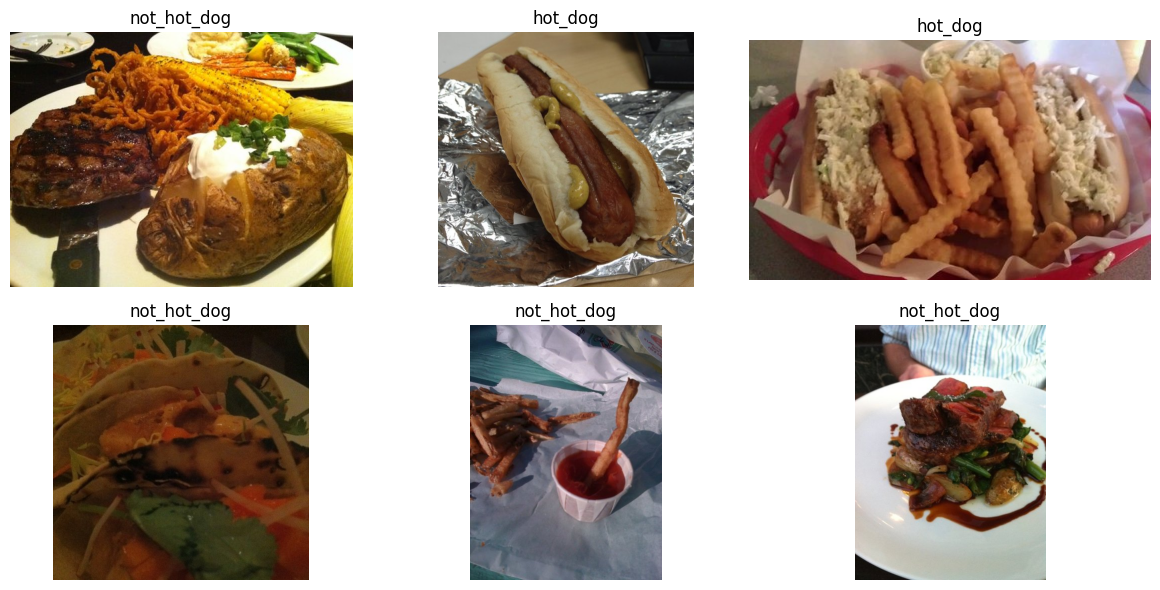

Image shape: (512, 512, 3)
Height: 512 pixels
Width: 512 pixels
Channels: 3 (RGB)


In [13]:
# Display 6 random images
plt.figure(figsize=(12, 6))
for i in range(6):
    # Pick random class
    class_name = random.choice(["hot_dog", "not_hot_dog"])
    class_path = os.path.join(train_path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)
    # Load and show image
    img = plt.imread(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')  # Fixed: straight quotes instead of curly quotes
plt.tight_layout()
plt.show()

# YOUR CODE HERE: Print the shape (height, width, channels) of one image
# Hint: Use img.shape after loading an image
# Load a sample image
sample_class = "hot_dog"
sample_path = os.path.join(train_path, sample_class)
sample_img_name = os.listdir(sample_path)[0]  # Get first image
sample_img_path = os.path.join(sample_path, sample_img_name)
sample_img = plt.imread(sample_img_path)

# Print the shape
print(f"Image shape: {sample_img.shape}")
print(f"Height: {sample_img.shape[0]} pixels")
print(f"Width: {sample_img.shape[1]} pixels")
if len(sample_img.shape) == 3:
    print(f"Channels: {sample_img.shape[2]} (RGB)")

In [17]:
# Set image size (YOUR CHOICE: 64x64 is faster, 128x128 is moreaccurate
IMG_HEIGHT = 64
IMG_WIDTH = 64
BATCH_SIZE = 32
# Create generators with automatic labeling
train_datagen = ImageDataGenerator(
rescale=1./255, # Normalize pixel values from 0-255 to 0-1
validation_split=0.2 # Use 20% of training data for validation
)
train_generator = train_datagen.flow_from_directory(
train_path,
target_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
class_mode='binary', # Binary classification (hot dog vs not), # Binary classification (hot dog vs not)
subset='training' # Training set (80% of data)
)
validation_generator = train_datagen.flow_from_directory(
train_path,
target_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
class_mode='binary',
subset='validation' # Validation set (20% of data)
)
# YOUR CODE HERE: Print the class labels
#
# Hint: Print train_generator.class_indices
print(train_generator.class_indices)

Found 400 images belonging to 2 classes.
Found 98 images belonging to 2 classes.
{'hot_dog': 0, 'not_hot_dog': 1}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,572,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,581,313 (6.03 MB)

 Trainable params: 1,581,313 (6.03 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 52s 4s/step - accuracy: 0.5075 - loss: 1.1577 - val_accuracy: 0.5102 - val_loss: 0.7770
Epoch 2/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - accuracy: 0.5975 - loss: 0.6654 - val_accuracy: 0.5000 - val_loss: 0.8290
Epoch 3/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 267ms/step - accuracy: 0.6275 - loss: 0.6320 - val_accuracy: 0.5000 - val_loss: 0.7953
Epoch 4/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - accuracy: 0.6450 - loss: 0.6301 - val_accuracy: 0.5102 - val_loss: 0.7627
Epoch 5/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.7025 - loss: 0.5531 - val_accuracy: 0.5102 - val_loss: 0.7200
Epoch 6/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 203ms/step - accuracy: 0.7775 - loss: 0.4958 - val_accuracy: 0.5510 - val_loss: 0.8397
Epoch 7/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 217ms/step - accuracy: 0.7625 - loss: 0.5023 - val_accuracy: 0.5000 - val_loss: 0.9099
Epoch 8/10
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 311ms/step - accuracy: 0.7025 - loss: 0.5416 - val_accuracy: 0.53

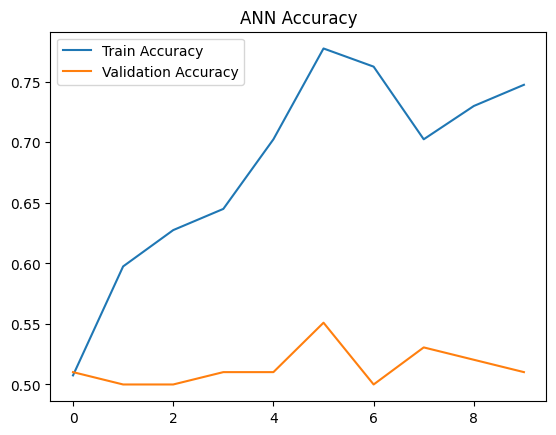

In [20]:
# Build a simple ANN
ann_model = keras.Sequential([
# Flatten the 2D image into 1D
layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
# Dense layers
layers.Dense(128, activation='relu'),
layers.Dense(64, activation='relu'),
layers.Dense(1, activation='sigmoid') # Output: probability of "hot dog"
])

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
# Show model summary
ann_model.summary()
# Train for 10 epochs
history_ann = ann_model.fit(train_generator, validation_data=
validation_generator, epochs=10)
# YOUR CODE HERE: Plot training vs validation accuracy.
#
#
# Hint: Use
# plt.plot(history_ann.history[’XXXX’], label=’XXXX’)
# plt.plot(history_ann.history[’XXXX’], label=’XXXX’)
plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("ANN Accuracy")
plt.show()

In [23]:
# Build a simple ANN
ann_model = keras.Sequential([
# Flatten the 2D image into 1D
layers.Flatten(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
# Dense layers
layers.Dense(128, activation='relu'),
layers.Dense(64, activation='relu'),
layers.Dense(1, activation='sigmoid') # Output: probability of "hot dog"
])

# Compile the model
ann_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
# Show model summary
ann_model.summary()
# Train for 10 epochs
history_ann = ann_model.fit(train_generator, validation_data=
validation_generator, epochs=10)
# YOUR CODE HERE: Plot training vs validation accuracy.
#
#
# Hint: Use
# plt.plot(history_ann.history[’XXXX’], label=’XXXX’)
# plt.plot(history_ann.history[’XXXX’], label=’XXXX’)
plt.plot(history_ann.history['accuracy'], label='Train Accuracy')
plt.plot(history_ann.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("ANN Accuracy")
plt.show()

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 483ms/step - accuracy: 0.5350 - loss: 0.7031 - val_accuracy: 0.5408 - val_loss: 0.6827
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 313ms/step - accuracy: 0.5075 - loss: 0.6869 - val_accuracy: 0.5510 - val_loss: 0.6777
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 286ms/step - accuracy: 0.6550 - loss: 0.6599 - val_accuracy: 0.5918 - val_loss: 0.6701
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 430ms/step - accuracy: 0.6500 - loss: 0.6264 - val_accuracy: 0.6224 - val_loss: 0.6415
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 354ms/step - accuracy: 0.7000 - loss: 0.5887 - val_accuracy: 0.6327 - val_loss: 0.6772
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 321ms/step - accuracy: 0.7275 - loss: 0.5585 - val_accuracy: 0.6531 - val_loss: 0.6645
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 433ms/step - accuracy: 0.7625 - loss: 0.5112 - val_accuracy: 0.6224 - val_loss: 0.6510
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 364ms/step - accuracy: 0.8150 - loss: 0.4568 - val_accuracy: 0.

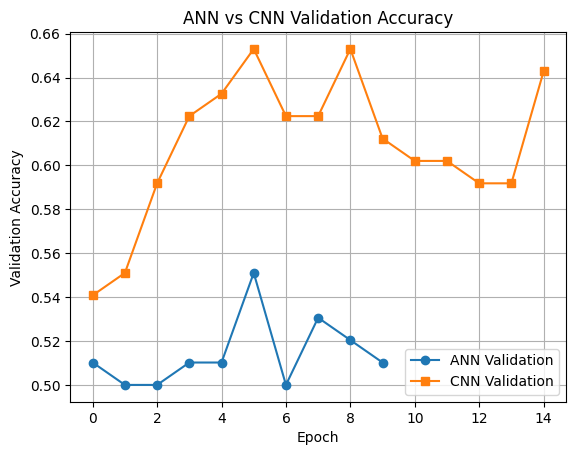

In [25]:
plt.plot(history_ann.history['val_accuracy'], label='ANN Validation', marker='o')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Validation', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('ANN vs CNN Validation Accuracy')
plt.grid(True)
plt.show()

In [34]:
from tensorflow.keras import regularizers
# Add dropout of 0.25, 0.25, and 0.5 after each MaxPooling layer respectively
improved_model = keras.Sequential([
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
IMG_HEIGHT, IMG_WIDTH, 3)),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25), # Add dropout
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25), # Add dropout
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.5), # Add dropout before output
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dense(1, activation='sigmoid')
])
# Recompile and Train the improved model (after addressing overfitting using dropout)
improved_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
history_improved = improved_model.fit(train_generator, validation_data=validation_generator, epochs=15)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 430ms/step - accuracy: 0.5125 - loss: 0.7235 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.5050 - loss: 0.6909 - val_accuracy: 0.5000 - val_loss: 0.6936
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 523ms/step - accuracy: 0.5050 - loss: 0.6939 - val_accuracy: 0.5714 - val_loss: 0.6895
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 332ms/step - accuracy: 0.5225 - loss: 0.6880 - val_accuracy: 0.5102 - val_loss: 0.6917
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 338ms/step - accuracy: 0.5675 - loss: 0.6863 - val_accuracy: 0.5918 - val_loss: 0.6867
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 490ms/step - accuracy: 0.6050 - loss: 0.6722 - val_accuracy: 0.5714 - val_loss: 0.6910
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 328ms/step - accuracy: 0.5775 - loss: 0.6668 - val_accuracy: 0.5510 - val_loss: 0.6985
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 335ms/step - accuracy: 0.6075 - loss: 0.6709 - val_accuracy: 0.

In [35]:
augmented_datagen = ImageDataGenerator(
rescale=1./255,
rotation_range=20,
width_shift_range=0.1,
height_shift_range=0.1,
horizontal_flip=True,
validation_split=0.2
)
train_augmented = augmented_datagen.flow_from_directory(
train_path,
target_size=(IMG_HEIGHT, IMG_WIDTH),
batch_size=BATCH_SIZE,
class_mode='binary',
subset='training'
)
# Then retrain the improved model with augmented_datagen
final_model = keras.Sequential([
# Same architecture as improved_model
layers.Conv2D(32, (3, 3), activation='relu', input_shape=(
IMG_HEIGHT, IMG_WIDTH, 3)),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Dropout(0.25),
layers.Conv2D(64, (3, 3), activation='relu'),
layers.MaxPooling2D((2, 2)),
layers.Flatten(),
layers.Dense(64, activation='relu'),
layers.Dropout(0.5),
layers.Dense(1, activation='sigmoid')
])
final_model.compile(optimizer='adam', loss='binary_crossentropy',
metrics=['accuracy'])
history_final = final_model.fit(train_augmented, validation_data=
validation_generator, epochs=15)

Found 400 images belonging to 2 classes.
Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 408ms/step - accuracy: 0.4975 - loss: 0.7188 - val_accuracy: 0.5306 - val_loss: 0.6926
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 521ms/step - accuracy: 0.5125 - loss: 0.6980 - val_accuracy: 0.4898 - val_loss: 0.6926
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step - accuracy: 0.4925 - loss: 0.6956 - val_accuracy: 0.5714 - val_loss: 0.6926
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 376ms/step - accuracy: 0.5125 - loss: 0.6930 - val_accuracy: 0.5000 - val_loss: 0.6928
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 465ms/step - accuracy: 0.5275 - loss: 0.6914 - val_accuracy: 0.5204 - val_loss: 0.6922
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 380ms/step - accuracy: 0.5550 - loss: 0.6897 - val_accuracy: 0.5816 - val_loss: 0.6912
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 456ms/step - accuracy: 0.5275 - loss: 0.6897 - val_accuracy: 0.5612 - val_loss: 0.6893
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 392ms/step - accuracy:

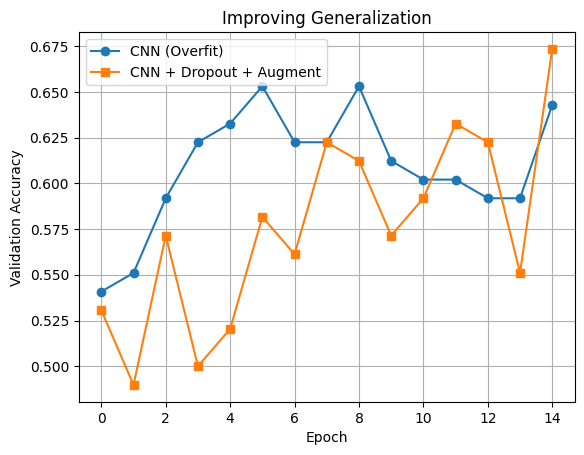

In [37]:
plt.plot(history_cnn.history['val_accuracy'], label='CNN (Overfit)', marker='o')
plt.plot(history_final.history['val_accuracy'], label='CNN + Dropout + Augment', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.title('Improving Generalization')
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
NOT A HOT DOG! (confidence: 0.58)


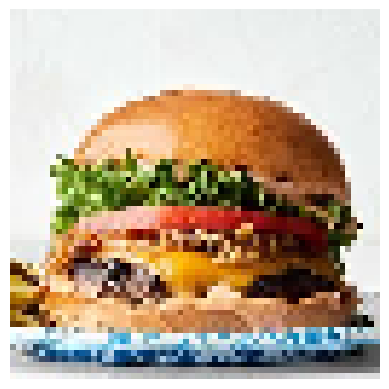

In [66]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

def predict_image_from_drive(img_path):
    # Load image from Google Drive path
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0

    # Predict
    prediction = final_model.predict(img_array)[0][0]
    if prediction > 0.5:
        print(f"HOT DOG! (confidence: {prediction:.2f})")
    else:
        print(f"NOT A HOT DOG! (confidence: {1-prediction:.2f})")

    # Show image
    plt.imshow(img)
    plt.axis('off')
    plt.show()

# Test with an image from Google Drive
# Replace with the actual path to your image in Google Drive

predict_image_from_drive("/BB.jpg")



image 1/1 /bin/WhatsApp Image 2026-05-03 at 3.59.42 PM.jpeg: 320x640 1 hot dog, 259.1ms
Speed: 11.1ms preprocess, 259.1ms inference, 33.8ms postprocess per image at shape (1, 3, 320, 640)


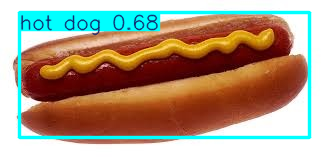

In [55]:
!pip install ultralytics
from ultralytics import YOLO

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt")  # n = nano (fast, small)

# Run detection on your hot dog image
results = yolo_model("/bin/WhatsApp Image 2026-05-03 at 3.59.42 PM.jpeg")

# Show results (it will draw boxes around objects it recognizes)
results[0].show()

In [71]:
!sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf /HotDog_Classifier_Hamza_Ahmad.ipynb

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
texlive-fonts-recommended is already the newest version (2021.20220204-1).
texlive-plain-generic is already the newest version (2021.20220204-1).
texlive-xetex is already the newest version (2021.20220204-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
[NbConvertApp] Converting notebook /HotDog_Classifier_Hamza_Ahmad.ipynb to pdf
[NbConvertApp] Support files will be in HotDog_Classifier_Hamza_Ahmad_files/
[NbConvertApp] Making directory ./HotDog_Classifier_Hamza_Ahmad_files
[NbConvertApp] Writing 73428 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 959929 bytes to /HotDog_Classifier

In [72]:
!jupyter nbconvert --to html /HotDog_Classifier_Hamza_Ahmad.ipynb

[NbConvertApp] Converting notebook /HotDog_Classifier_Hamza_Ahmad.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 1679493 bytes to /HotDog_Classifier_Hamza_Ahmad.html



image 1/1 /PIZA.jpg: 384x640 2 persons, 3 pizzas, 128.5ms
Speed: 2.7ms preprocess, 128.5ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


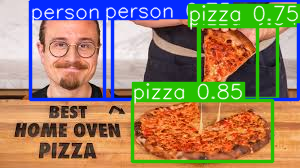

In [68]:

!pip install ultralytics
from ultralytics import YOLO

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt")  # n = nano (fast, small)

# Run detection on your hot dog image
results = yolo_model("/PIZA.jpg")

# Show results (it will draw boxes around objects it recognizes)
results[0].show()


image 1/1 /PPCC.jpg: 480x640 1 truck, 1 pizza, 189.1ms
Speed: 3.3ms preprocess, 189.1ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)


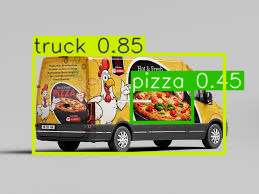

In [70]:

!pip install ultralytics
from ultralytics import YOLO

# Load a tiny pre-trained model
yolo_model = YOLO("yolov8n.pt")  # n = nano (fast, small)

# Run detection on your hot dog image
results = yolo_model("/PPCC.jpg")

# Show results (it will draw boxes around objects it recognizes)
results[0].show()